# Step 1: Data Loading and Exploration

In [2]:
#import libraries and load dataframes

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings                                                                             
warnings.filterwarnings('ignore')

train_data = pd.read_csv('training_data.csv')                                               
test_data = pd.read_csv('testing_data.csv')
                                                                                          
print(f"Training: {len(train_data):,} rows, {train_data['PatientID'].nunique():,} patients")
print(f"Testing:  {len(test_data):,} rows, {test_data['PatientID'].nunique():,} patients")
print(f"\nColumns: {len(train_data.columns)} total")                                        
print(f"Data types:\n{train_data.dtypes}")      

Training: 1,165,460 rows, 30,253 patients
Testing:  386,750 rows, 10,083 patients

Columns: 43 total
Data types:
PatientID            object
Hour                  int64
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                

# Step 2: Exploratory Data Analysis

## 2.1 Overview and Structure

In [3]:
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")                                                          
print("=" * 80) 
print(f"\nDataset Shape:")                                                                  
print(f"  Training: {train_data.shape}")
print(f"  Testing: {test_data.shape}")                                                      
              
# Column names
id_cols = ['PatientID', 'Hour', 'SepsisLabel']
clinical_cols = [c for c in train_data.columns if c not in id_cols]                         
                                                                                          
print(f"\nClinical variables: {len(clinical_cols)}")                                        
print(f"  {clinical_cols}")

EXPLORATORY DATA ANALYSIS

Dataset Shape:
  Training: (1165460, 43)
  Testing: (386750, 43)

Clinical variables: 40
  ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']


## 2.2 Class Imbalance Visualization


CLASS IMBALANCE

Training set:
No sepsis (0): 1,143,161(98.09%)
Sepsis (1): 22,299(1.91%)

Testing set:
No sepsis (0): 381,133 (98.55%)
Sepsis (1): 5,617(1.45%)


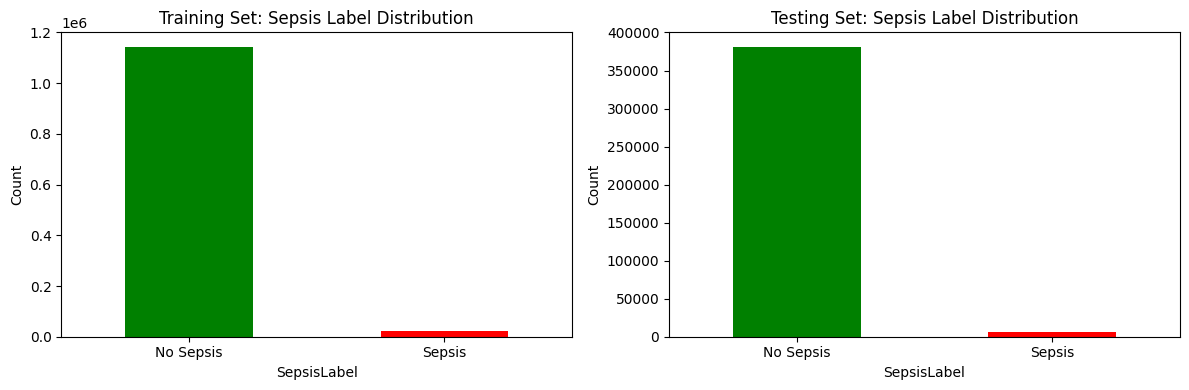


⚠ Major class imbalance: ~2% sepsis, 98% non-sepsis
  → Mitigation: class_weight='balanced', AUPRC metric, PhysioNet utility score


In [4]:
# Sepsis prevalence
sepsis_count_train = (train_data['SepsisLabel'] == 1).sum()
sepsis_count_test = (test_data['SepsisLabel'] == 1).sum()                                   

print(f"\n{'='*80}")                                                                        
print("CLASS IMBALANCE")
print(f"{'='*80}")                                                                          

print(f"\nTraining set:")                                                                   
print(f"No sepsis (0): {(train_data['SepsisLabel'] == 0).sum():,}({100*(train_data['SepsisLabel'] == 0).mean():.2f}%)")                                      
print(f"Sepsis (1): {sepsis_count_train:,}({100*sepsis_count_train/len(train_data):.2f}%)")                                           
              
print(f"\nTesting set:")                                                                    
print(f"No sepsis (0): {(test_data['SepsisLabel'] == 0).sum():,} ({100*(test_data['SepsisLabel'] == 0).mean():.2f}%)")                                       
print(f"Sepsis (1): {sepsis_count_test:,}({100*sepsis_count_test/len(test_data):.2f}%)")
                                                                                          
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                                                                                          
train_data['SepsisLabel'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])                                                                                     
axes[0].set_title('Training Set: Sepsis Label Distribution')
axes[0].set_xticklabels(['No Sepsis', 'Sepsis'], rotation=0)
axes[0].set_ylabel('Count')                                                                 

test_data['SepsisLabel'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Testing Set: Sepsis Label Distribution')
axes[1].set_xticklabels(['No Sepsis', 'Sepsis'], rotation=0)                                
axes[1].set_ylabel('Count')
                                                                                          
plt.tight_layout()
plt.show()
                                                                                          
print("\n⚠ Major class imbalance: ~2% sepsis, 98% non-sepsis")                              
print("  → Mitigation: class_weight='balanced', AUPRC metric, PhysioNet utility score")  

## 2.3 Missing Data Analysis


MISSING DATA PATTERNS

Missing data by variable (Training set):
        Variable  Missing_Count  Missing_Percent
Bilirubin_direct        1163402        99.823417
       TroponinI        1157581        99.323958
      Fibrinogen        1157310        99.300705
 Bilirubin_total        1149139        98.599609
    Alkalinephos        1147313        98.442932
             AST        1147052        98.420538
           EtCO2        1138169        97.658349
         Lactate        1131375        97.075404
             PTT        1123469        96.397045
            SaO2        1119369        96.045253
       Phosphate        1114584        95.634685
            HCO3        1101181        94.484667
         Calcium        1100486        94.425034
        Chloride        1097317        94.153124
       Platelets        1093876        93.857876
      Creatinine        1092158        93.710466
           PaCO2        1087891        93.344345
             WBC        1086325        93.209977
    

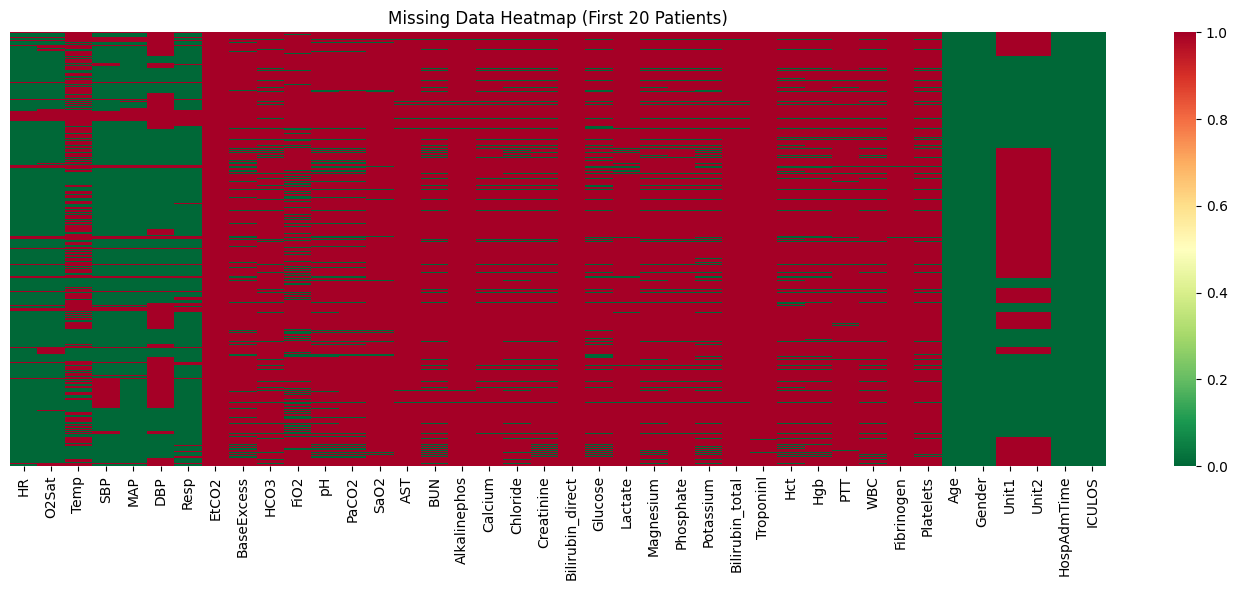


Key insight: Sepsis patients often have MORE frequent measurements
  → Missing is NOT random; sicker → more labs
  → Strategy: Forward-fill + measurement indicator flags


In [5]:
print(f"\n{'='*80}")                                                                        
print("MISSING DATA PATTERNS")
print(f"{'='*80}")

# Missing data per variable
missing_train = train_data[clinical_cols].isnull().sum()
missing_pct = 100 * missing_train / len(train_data)                                         
missing_df = pd.DataFrame({                                                                 
  'Variable': clinical_cols,                                                              
  'Missing_Count': missing_train.values,                                                  
  'Missing_Percent': missing_pct.values
}).sort_values('Missing_Percent', ascending=False)                                          

print("\nMissing data by variable (Training set):")                                         
print(missing_df[missing_df['Missing_Percent'] > 0].to_string(index=False))
                                                                                          
# Visualize missing data heatmap (sample of patients)                                       
sample_patients = train_data['PatientID'].unique()[:20]
sample_data = train_data[train_data['PatientID'].isin(sample_patients)][clinical_cols]      
              
fig, ax = plt.subplots(figsize=(14, 6))                                                     
sns.heatmap(sample_data.isnull(), cbar=True, cmap='RdYlGn_r', ax=ax, yticklabels=False)
ax.set_title('Missing Data Heatmap (First 20 Patients)')                                    
plt.tight_layout()
plt.show()                                                                                  
              
print("\nKey insight: Sepsis patients often have MORE frequent measurements")               
print("  → Missing is NOT random; sicker → more labs")
print("  → Strategy: Forward-fill + measurement indicator flags")

## 2.4 Clinical Variable Distributions


CLINICAL VARIABLE DISTRIBUTIONS

Summary statistics (Training set):
               HR       O2Sat       Temp        SBP         MAP        DBP  \
count  1058957.00  1017592.00  393633.00  992976.00  1029215.00  732799.00   
mean        84.73       97.22      36.99     122.73       81.10      62.72   
std         17.24        2.94       0.78      22.67       15.97      13.67   
min         20.00       20.00      20.90      20.00       20.00      20.00   
25%         72.00       96.00      36.50     106.00       70.00      53.00   
50%         84.00       98.00      37.00     120.00       79.00      61.00   
75%         96.00       99.50      37.50     137.00       90.00      70.00   
max        280.00      100.00      50.00     299.00      300.00     300.00   

             Resp     EtCO2  BaseExcess      HCO3  ...       PTT       WBC  \
count  1008763.00  27291.00    83192.00  64279.00  ...  41991.00  79135.00   
mean        18.75     33.04       -0.67     24.08  ...     41.04     11.

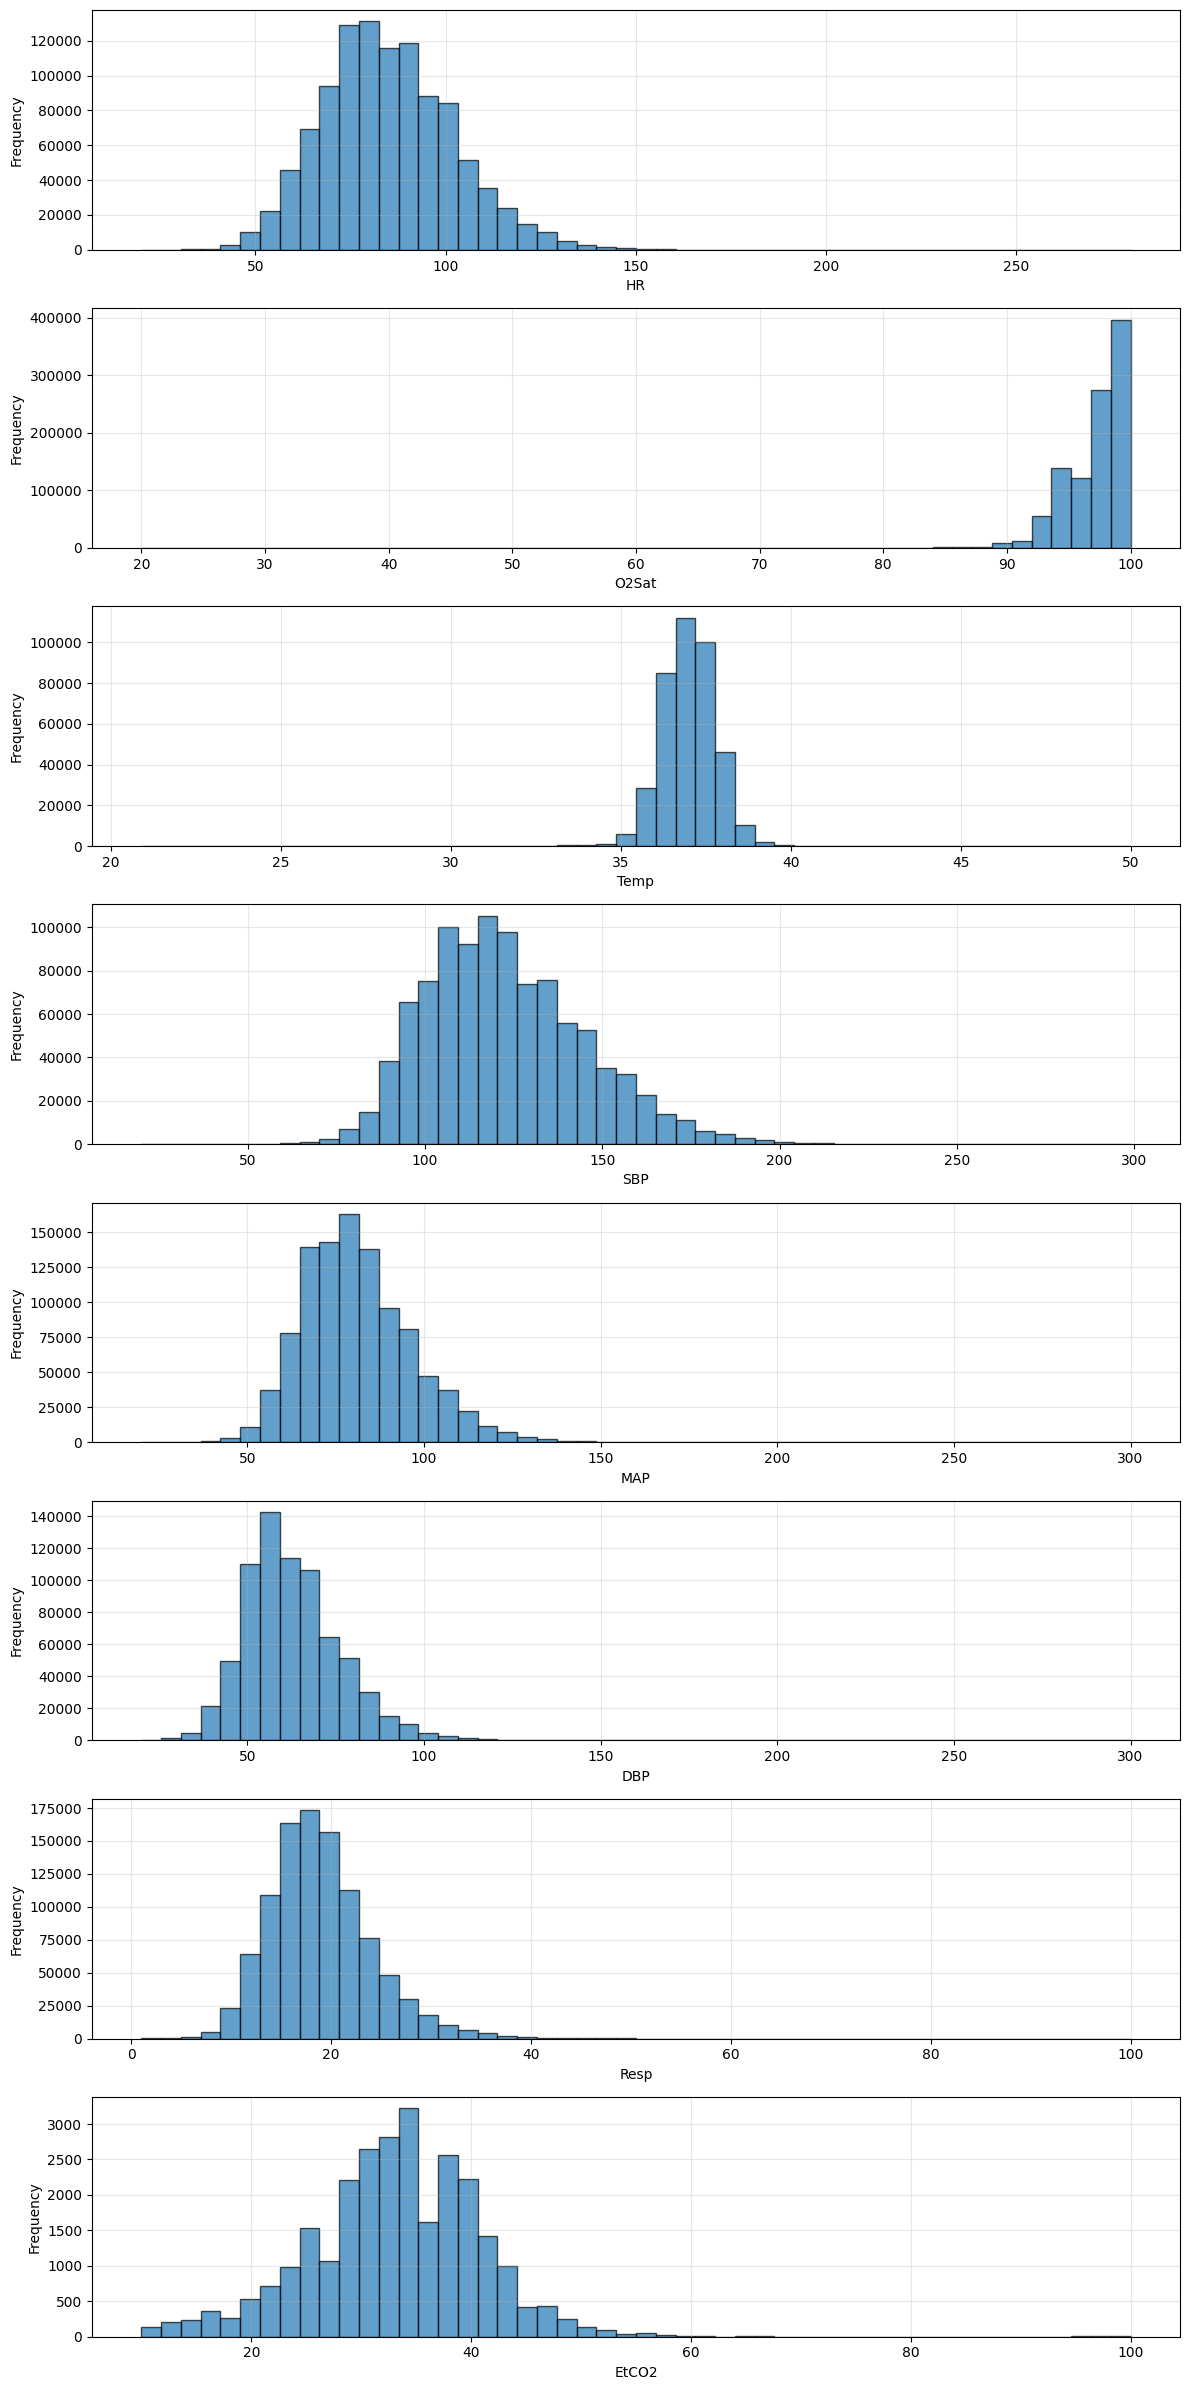


Comparison of key variables by sepsis status:
                HR  O2Sat   Temp     SBP    MAP
SepsisLabel                                    
0            84.61  97.22  36.99  122.76  81.13
1            90.51  97.03  37.24  121.02  79.42


In [6]:
print(f"\n{'='*80}")
print("CLINICAL VARIABLE DISTRIBUTIONS")
print(f"{'='*80}")                                                                          

# Summary statistics                                                                        
print("\nSummary statistics (Training set):")
print(train_data[clinical_cols].describe().round(2))

# Visualize distributions of key variables                                                  
key_vars = clinical_cols[:8] if len(clinical_cols) >= 8 else clinical_cols
                                                                                          
fig, axes = plt.subplots(len(key_vars), 1, figsize=(12, 3*len(key_vars)))
if len(key_vars) == 1:                                                                      
  axes = [axes]
                                                                                          
for idx, var in enumerate(key_vars):
  axes[idx].hist(train_data[var].dropna(), bins=50, alpha=0.7, edgecolor='black')         
  axes[idx].set_xlabel(var)
  axes[idx].set_ylabel('Frequency')                                                       
  axes[idx].grid(True, alpha=0.3)
                                                                                          
plt.tight_layout()
plt.show()

# Comparison: sepsis vs non-sepsis patients                                                 
print("\nComparison of key variables by sepsis status:")
comparison = train_data.groupby('SepsisLabel')[clinical_cols[:5]].mean()                    
print(comparison.round(2)) 

## 2.5 Temporal Patterns

In [11]:
print(f"\n{'='*80}")                                                                        
print("TEMPORAL PATTERNS: HOW DO VITALS CHANGE OVER TIME?")
print(f"{'='*80}")                                                                          

# Pick a sepsis patient and a non-sepsis patient                                            
sepsis_patients = train_data[train_data['SepsisLabel'] == 1]['PatientID'].unique()
non_sepsis_patients = train_data[train_data['SepsisLabel'] == 0]['PatientID'].unique()      
                                                                                          
sepsis_pid = sepsis_patients[0]                                                             
non_sepsis_pid = non_sepsis_patients[0]                                                     
              
sepsis_patient_data = train_data[train_data['PatientID'] == sepsis_pid].sort_values('Hour') 
non_sepsis_patient_data = train_data[train_data['PatientID'] ==
non_sepsis_pid].sort_values('Hour')                                                         
              
print(f"\nExample 1: Sepsis patient {sepsis_pid}")                                          
print(f"Hours in ICU: {len(sepsis_patient_data)}")
print(f"Sepsis onset at hour: {sepsis_patient_data[sepsis_patient_data['SepsisLabel'] ==  1]['Hour'].min()}")                                                                         
                                                                                          
print(f"\nExample 2: Non-sepsis patient {non_sepsis_pid}")                                  
print(f"Hours in ICU: {len(non_sepsis_patient_data)}")
print(f"Never develops sepsis")                                                           


TEMPORAL PATTERNS: HOW DO VITALS CHANGE OVER TIME?

Example 1: Sepsis patient p000009
Hours in ICU: 258
Sepsis onset at hour: 248

Example 2: Non-sepsis patient p000001
Hours in ICU: 54
Never develops sepsis


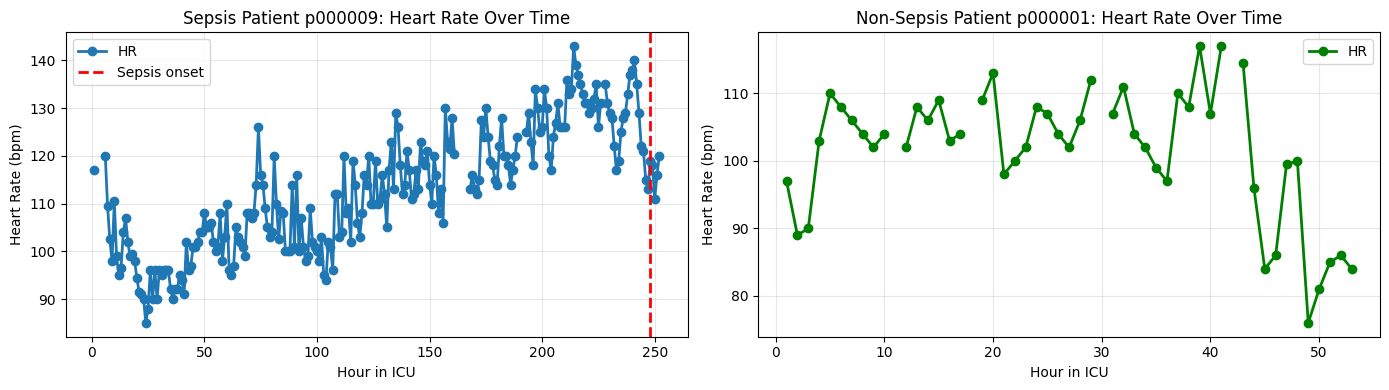

In [13]:
# Visualize trajectories                                                                    
if 'HR' in clinical_cols:
  fig, axes = plt.subplots(1, 2, figsize=(14, 4))                                         

  # Heart Rate trajectory for sepsis patient                                              
  axes[0].plot(sepsis_patient_data['Hour'], sepsis_patient_data['HR'], marker='o', label='HR', linewidth=2)                                                                    
  sepsis_onset = sepsis_patient_data[sepsis_patient_data['SepsisLabel'] == 1]['Hour'].min()                                                                            
  axes[0].axvline(sepsis_onset, color='red', linestyle='--', linewidth=2, label='Sepsis onset')                                                                                     
  axes[0].set_xlabel('Hour in ICU')
  axes[0].set_ylabel('Heart Rate (bpm)')                                                  
  axes[0].set_title(f'Sepsis Patient {sepsis_pid}: Heart Rate Over Time')
  axes[0].legend()                                                                        
  axes[0].grid(True, alpha=0.3)
                                                                                          
  # Heart Rate for non-sepsis patient
  axes[1].plot(non_sepsis_patient_data['Hour'], non_sepsis_patient_data['HR'], marker='o', label='HR', linewidth=2, color='green')                                                    
  axes[1].set_xlabel('Hour in ICU')
  axes[1].set_ylabel('Heart Rate (bpm)')                                                  
  axes[1].set_title(f'Non-Sepsis Patient {non_sepsis_pid}: Heart Rate Over Time')
  axes[1].legend()                                                                        
  axes[1].grid(True, alpha=0.3)
                                                                                          
  plt.tight_layout()
  plt.show()                                                                              


When does sepsis occur in patient stays?


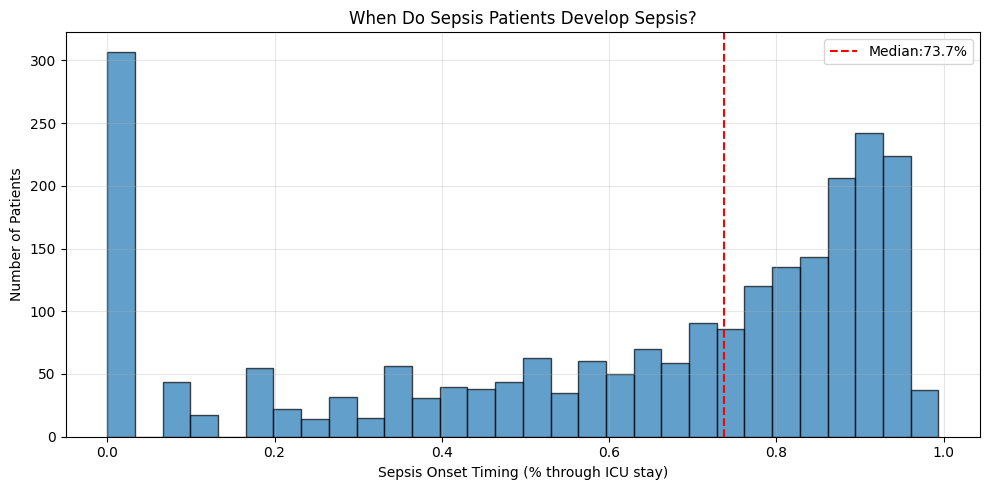


Sepsis onset statistics:
Mean: 61.0% through ICU stay
Median: 73.7%
Range: 0.0% to 99.4%


In [15]:
# Sepsis onset timing in patient trajectory                                                 
print(f"\nWhen does sepsis occur in patient stays?")
sepsis_onsets = []                                                                          
for pid in sepsis_patients:
  patient_df = train_data[train_data['PatientID'] == pid]                                 
  sepsis_hours = patient_df[patient_df['SepsisLabel'] == 1]['Hour'].values                
  if len(sepsis_hours) > 0:
      onset_hour = sepsis_hours[0]                                                        
      total_hours = len(patient_df)                                                       
      sepsis_onsets.append(onset_hour / total_hours)
                                                                                          
fig, ax = plt.subplots(figsize=(10, 5))                                                     
ax.hist(sepsis_onsets, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Sepsis Onset Timing (% through ICU stay)')                                   
ax.set_ylabel('Number of Patients')                                                         
ax.set_title('When Do Sepsis Patients Develop Sepsis?')
ax.axvline(np.median(sepsis_onsets), color='red', linestyle='--', label=f'Median:{np.median(sepsis_onsets):.1%}')                                                            
ax.legend()                                                                                 
ax.grid(True, alpha=0.3)                                                                    
plt.tight_layout()
plt.show()                                                                                  

print(f"\nSepsis onset statistics:")                                                        
print(f"Mean: {np.mean(sepsis_onsets):.1%} through ICU stay")
print(f"Median: {np.median(sepsis_onsets):.1%}")                                          
print(f"Range: {np.min(sepsis_onsets):.1%} to {np.max(sepsis_onsets):.1%}")

## 2.6 Correlation Analysis


CORRELATION WITH SEPSIS OUTCOME

Top 10 variables most correlated with sepsis:
ICULOS              0.143
Fibrinogen          0.053
Bilirubin_direct    0.052
BUN                 0.051
Resp                0.049
HR                  0.047
Temp                0.044
Bilirubin_total     0.040
Unit1               0.036
TroponinI           0.034
Name: SepsisLabel, dtype: float64

Top 10 variables least correlated (possibly uninformative):
Chloride      -0.009
SBP           -0.010
DBP           -0.012
Hct           -0.013
HCO3          -0.014
MAP           -0.015
Hgb           -0.018
HospAdmTime   -0.019
Calcium       -0.032
Unit2         -0.036
Name: SepsisLabel, dtype: float64


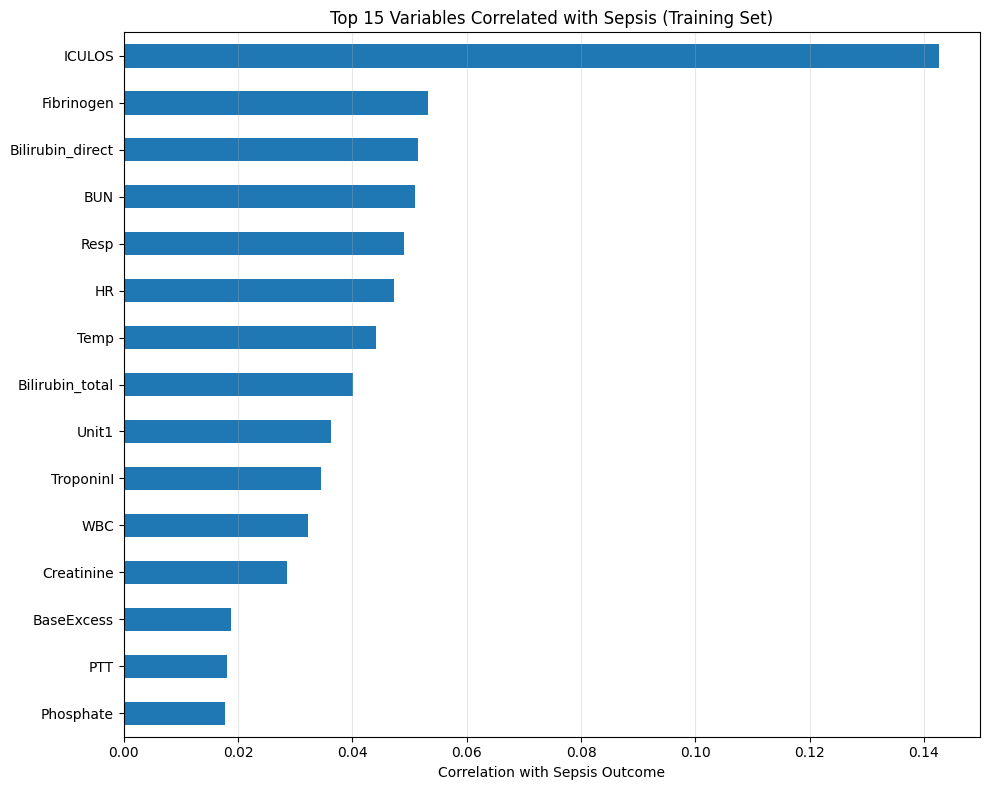

In [16]:
print(f"\n{'='*80}")
print("CORRELATION WITH SEPSIS OUTCOME")
print(f"{'='*80}")

# Correlation of clinical variables with sepsis                                             
correlations = train_data[clinical_cols +
['SepsisLabel']].corr()['SepsisLabel'].drop('SepsisLabel')                                  
correlations = correlations.sort_values(ascending=False)
                                                                                          
print("\nTop 10 variables most correlated with sepsis:")
print(correlations.head(10).round(3))
                                                                                          
print("\nTop 10 variables least correlated (possibly uninformative):")                      
print(correlations.tail(10).round(3))                                                       
                                                                                          
# Visualize     
fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(15).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Correlation with Sepsis Outcome')                                            
ax.set_title('Top 15 Variables Correlated with Sepsis (Training Set)')
ax.grid(True, alpha=0.3, axis='x')                                                          
plt.tight_layout()
plt.show()

## 2.7 ICU Characteristics Summary


ICU CHARACTERISTICS

ICU stay length (Training set):
Mean: 38.5 hours
Median: 39.0 hours
Min: 8 hours
Max: 336 hours


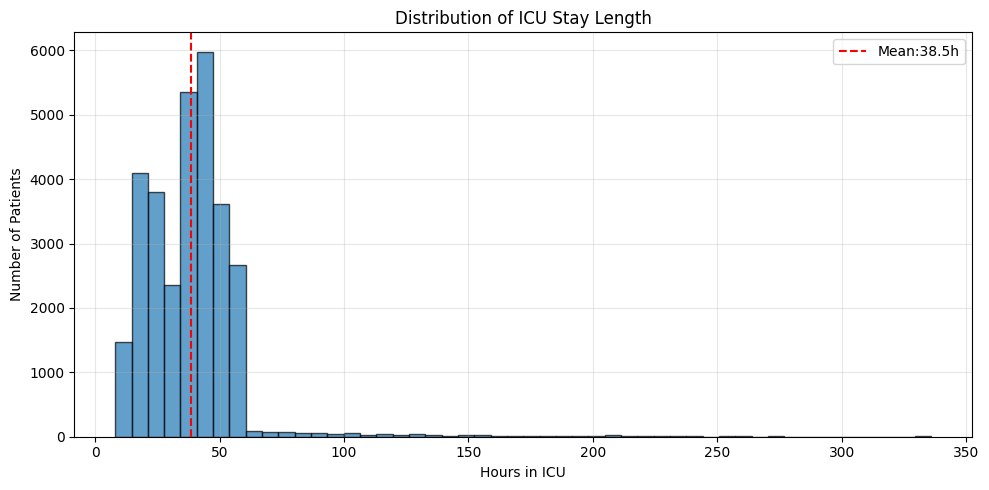


Comparison: Sepsis vs Non-Sepsis Patients
With sepsis: 2336 patients (7.7%)
Without sepsis: 27917 patients (92.3%)

Mean ICU stay length by sepsis status:
Sepsis patients: 58.6 hours (median: 37.0)
Non-sepsis patients: 36.8 hours (median: 39.0)


In [21]:
print(f"\n{'='*80}")                                                                        
print("ICU CHARACTERISTICS")
print(f"{'='*80}")

# Hours per patient                                                                         
hours_per_patient_train = train_data.groupby('PatientID').size()
                                                                                          
print(f"\nICU stay length (Training set):")
print(f"Mean: {hours_per_patient_train.mean():.1f} hours")                                
print(f"Median: {hours_per_patient_train.median():.1f} hours")                            
print(f"Min: {hours_per_patient_train.min():.0f} hours")
print(f"Max: {hours_per_patient_train.max():.0f} hours")                                  
              
fig, ax = plt.subplots(figsize=(10, 5))                                                     
ax.hist(hours_per_patient_train, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Hours in ICU')                                                               
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of ICU Stay Length')                                             
ax.axvline(hours_per_patient_train.mean(), color='red', linestyle='--', label=f'Mean:{hours_per_patient_train.mean():.1f}h')                                                     
ax.legend()                                                                                 
ax.grid(True, alpha=0.3)                                                                    
plt.tight_layout()
plt.show()

# Sepsis patients vs non-sepsis                                                             
print(f"\nComparison: Sepsis vs Non-Sepsis Patients")
sepsis_flag = train_data.groupby('PatientID')['SepsisLabel'].max()                          
sepsis_stays = (sepsis_flag == 1).sum()                                                     
non_sepsis_stays = (sepsis_flag == 0).sum()
                                                                                          
print(f"With sepsis: {sepsis_stays} patients ({100*sepsis_stays/(sepsis_stays+non_sepsis_stays):.1f}%)")                                 
print(f"Without sepsis: {non_sepsis_stays} patients ({100*non_sepsis_stays/(sepsis_stays+non_sepsis_stays):.1f}%)")                             

hours_sepsis = train_data[train_data['PatientID'].isin(sepsis_flag[sepsis_flag==1].index)].groupby('PatientID').size()
hours_non_sepsis = train_data[train_data['PatientID'].isin(sepsis_flag[sepsis_flag==0].index)].groupby('PatientID').size()                                                              

print(f"\nMean ICU stay length by sepsis status:")                                               
print(f"Sepsis patients: {hours_sepsis.mean():.1f} hours (median: {hours_sepsis.median():.1f})")                                                              
print(f"Non-sepsis patients: {hours_non_sepsis.mean():.1f} hours (median: {hours_non_sepsis.median():.1f})")   

## 2.8 EDA Summary

In [23]:
print(f"\n{'='*80}")
print("EDA SUMMARY & KEY INSIGHTS")
print(f"{'='*80}")                                                                          
  
print(f"""                                                                                  
1. CLASS IMBALANCE (Major)
 - Training: {100*sepsis_count_train/len(train_data):.2f}% sepsis, {100*(1 -              
sepsis_count_train/len(train_data)):.2f}% non-sepsis                                        
 - Action: Use class_weight='balanced', AUPRC metric, utility score optimization          
                                                                                              
2. MISSING DATA (Common)
 - Some variables highly sparse (>50% missing)                                            
 - Missing data is MNAR: sicker patients → more labs measured                             
 - Action: Forward-fill within patient + indicator variables for "was measured?"          
                                                                                              
3. TEMPORAL PATTERNS (Key for prediction)                                                   
 - Sepsis manifests as TRENDS, not single points                                          
 - Vitals change over hours before onset                                                  
 - Action: Build rolling statistics (6h, 12h, 24h windows)
                                                                                              
4. SEPSIS ONSET TIMING
 - Sepsis typically develops {np.median(sepsis_onsets):.0%} through patient stay          
 - Slow insidious vs. sudden: variable presentations
 - Action: Capture multi-scale trends                                                     
                                                                                              
5. VARIABLE IMPORTANCE                                                                      
 - Most correlated: {correlations.index[0]}, {correlations.index[1]},                     
{correlations.index[2]}
 - NOTE: Correlations are very weak: ICULOS (0.14), Fibrinogen (0.53), Bilirubin (0.52)
 - Least correlated (possibly remove): {correlations.index[-1]}, {correlations.index[-2]}
                                                                                              
6. ICU CHARACTERISTICS
 - Typical stay: {hours_per_patient_train.median():.0f} hours                             
 - Sepsis patients tend to stay longer (sicker at baseline)
                                                                                          
NEXT: Feature engineering to capture these temporal patterns
""")   


EDA SUMMARY & KEY INSIGHTS
                                                                                  
1. CLASS IMBALANCE (Major)
 - Training: 1.91% sepsis, 98.09% non-sepsis                                        
 - Action: Use class_weight='balanced', AUPRC metric, utility score optimization          
                                                                                              
2. MISSING DATA (Common)
 - Some variables highly sparse (>50% missing)                                            
 - Missing data is MNAR: sicker patients → more labs measured                             
 - Action: Forward-fill within patient + indicator variables for "was measured?"          
                                                                                              
3. TEMPORAL PATTERNS (Key for prediction)                                                   
 - Sepsis manifests as TRENDS, not single points                                          
 - Vitals chan

# Step 3: Time-Series Preprocessing

## 3.1 Handle Irregular Sampling and Missing Values

In [25]:
def preprocess_timeseries(df):
  """
  Handle irregularly-sampled time-series data.
  Strategy: Forward-fill + measurement indicator flags
  Reasoning: By assuming that the last recorded measurement remains stable and valid until a new one is taken, we can resolve missing data in the dataframe
  """                                                                                     
                                                                                          
  # Separate ID/label columns from clinical variables                                     
  id_cols = ['PatientID', 'Hour', 'SepsisLabel']
  clinical_cols = [c for c in df.columns if c not in id_cols]                             
                                                                                          
  # Create a copy
  df_clean = df.copy()                                                                    
              
  # For each patient, forward-fill missing values within that patient                     
  for pid in tqdm(df_clean['PatientID'].unique(), desc="Filling missing values"):
      patient_mask = df_clean['PatientID'] == pid                                         
                                                                                          
      # Forward fill within this patient only
      for col in clinical_cols:                                                           
          df_clean.loc[patient_mask, col] = \
              df_clean.loc[patient_mask, col].fillna(method='ffill').fillna(method='bfill')                                          
                                                                                          
  # Create indicator variables: 1 if value was originally missing                         
  for col in clinical_cols:
      df_clean[f'{col}_missing'] = df[col].isnull().astype(int)
                                                                                          
  return df_clean
                                                                                          
train_clean = preprocess_timeseries(train_data)
test_clean = preprocess_timeseries(test_data)
                                                                                          
print(f"After preprocessing:")
print(f"Remaining NaNs in training: {train_clean.isnull().sum().sum()}") 

Filling missing values: 100%|█████████████| 10083/10083 [03:54<00:00, 43.06it/s]


After preprocessing:
Remaining NaNs in training: 13078849


**NOTE: The above cell takes approx ~30 minutes to run!** 

## 3.2 Normalize/Standardize Clinical Values

In [26]:
from sklearn.preprocessing import StandardScaler                                            
                  
# Fit scaler on TRAINING data only                                                          
id_cols = ['PatientID', 'Hour', 'SepsisLabel']
clinical_cols = [c for c in train_clean.columns if c not in id_cols and not c.endswith('_missing')]
scaler = StandardScaler()
scaler.fit(train_clean[clinical_cols])

# Apply to both train and test                                                              
train_scaled = train_clean.copy()
test_scaled = test_clean.copy()                                                             
              
train_scaled[clinical_cols] = scaler.transform(train_clean[clinical_cols])                  
test_scaled[clinical_cols] = scaler.transform(test_clean[clinical_cols])
                                                                                          
print(f"Scaled {len(clinical_cols)} clinical variables")

Scaled 40 clinical variables


# Step 4: Time-Series Feature Engineering